## Konteksts

Mēs strādājam ar e-komercijas vietnes "DataShop" sesiju datiem. Mērķis ir prognozēt `PageValues` — lapas vērtību, kas atspoguļo, cik tuvu klients bija pirkuma veikšanai. Augstāka vērtība nozīmē augstāku pirkuma varbūtību. Šī informācija palīdz mārketinga komandai noteikt, kuriem klientiem vērts rādīt papildu piedāvājumus.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 1. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('../week1/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


PageValues statistika:
count    1.233000e+04
mean     9.220344e-18
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


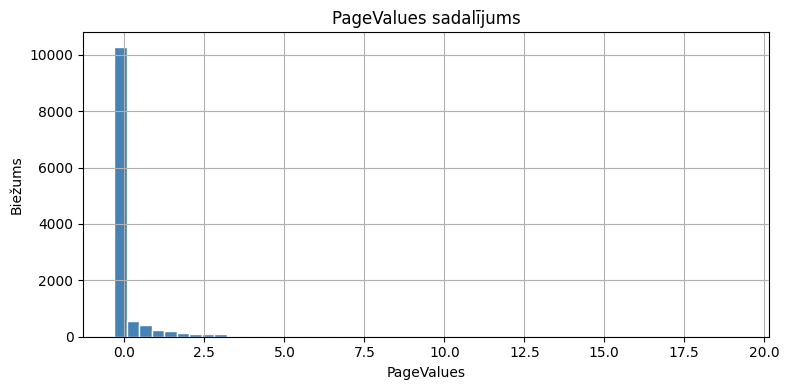

In [2]:
# Apskatām target mainīgo
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()

In [3]:
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")

Features skaits: 26
Target: PageValues


Mēs izņēmām `Revenue` kolonnu no features, jo tas ir **data leakage** piemērs.
Data leakage notiek, kad modelis treniņa laikā saņem informāciju, kas reālajā situācijā nebūtu pieejama. `Revenue` tieši atspoguļo, vai pirkums notika — tas ir rezultāts, nevis cēlonis. Ja to iekļautu features, modelis "apmānītu" pats sevi: tas mācītos no atbildes, nevis no datiem, kas līdz tai noved.
Biznesa vidē šāds modelis praksē nedarbotos — reālā sesijā `Revenue` vēl nav zināms.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineāra regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== Lineāra regresija: rezultāti ===
MSE:  0.9892
RMSE: 0.9946
MAE:  0.5009
R²:   0.0456


**MAE (Mean Absolute Error) = 0.5009**
Vidēji modelis kļūdās par 0.5009 vienībām. MAE ir viegli saprotams — ja MAE = 5, tad vidēji prognoze atšķiras no realitātes par 5 PageValues vienībām.

**RMSE (Root Mean Squared Error) = 0.9946**
RMSE soda lielākas kļūdas vairāk nekā mazās, jo kļūdas tiek kāpinātas kvadrātā pirms vidējošanas. Tas nozīmē, ka viens ļoti neprecīzs rezultāts var stipri paaugstināt RMSE, pat ja pārējie ir labi.

**R² = 0.0456**
R² parāda, cik lielu daļu no target mainīgā variācijas modelis izskaidro.
Mūsu gadījumā 0.0456 nozīmē, ka modelis izskaidro tikai 4.6% no PageValues svārstībām — pārējais 95.4% ir "troksnis", ko modelis nespēj uztvert.

**Vai modelis ir labs?**
Ar R² zem 0.5 modelis uzskatāms par vāju. PageValues ir stipri sašķiebts sadalījums (lielākā daļa vērtību ir 0), kuru lineārai regresijai ir grūti modelēt — tāpēc ir gaidāmi zemāki rādītāji.

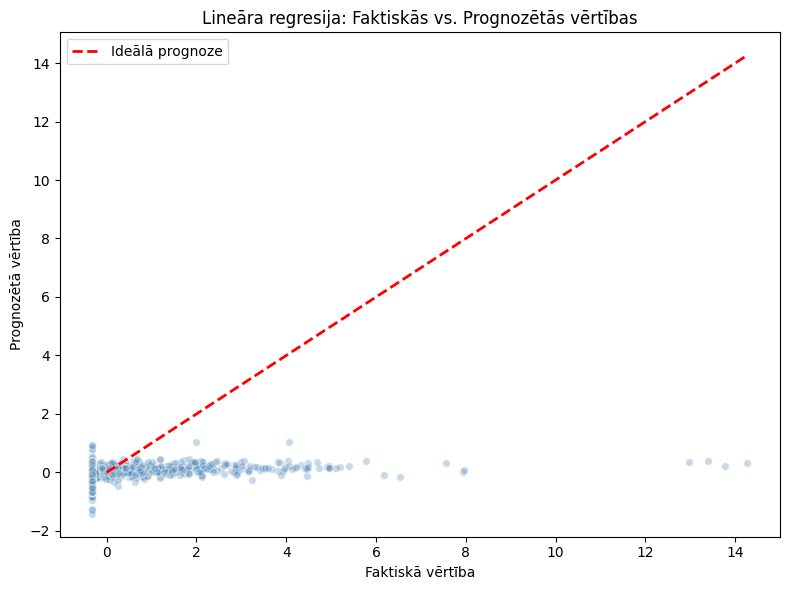

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

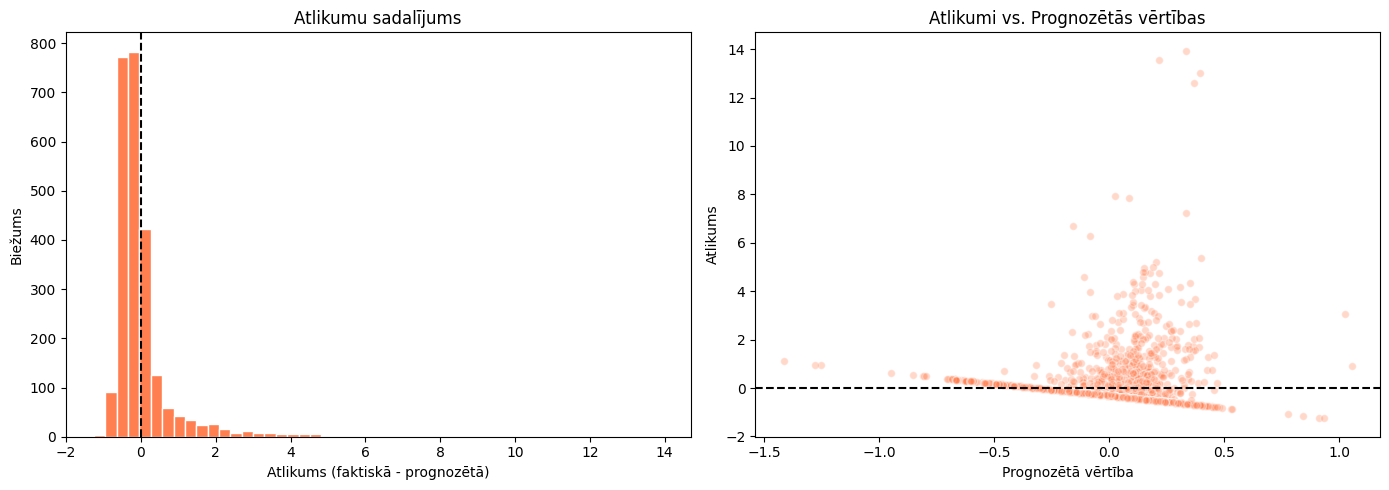

In [7]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

**Scatter grafiks (faktiskās vs. prognozētās):**
Punkti ir stipri izkliedēti ap sarkano līniju, nevis tuvu tai — tas liecina, ka modelis bieži kļūdās, īpaši pie augstākām PageValues vērtībām.
Ideālā gadījumā punkti būtu tieši uz sarkanās līnijas.

**Atlikumu histogramma:**
Atlikumi nav simetriski sadalīti ap 0 — ir redzams nobīde pa labi vai pa kreisi, kas norāda uz sistemātisku kļūdu (bias). Ideāli atlikumiem vajadzētu izskatīties kā normālsadalījumam ar centru 0.

**Atlikumi vs. prognozētās vērtības:**
Punkti nav nejauši izkaisīti — ir redzama struktūra (piemēram, lielas kļūdas pie lielām prognozētām vērtībām). Tas liecina par heteroskedasticitāti —
modelis ir mazāk precīzs augstākajās vērtībās.

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Izveido pipeline: PolynomialFeatures → LinearRegression
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# Trenēšana
poly_pipeline.fit(X_train, y_train)

# Prognozes
y_pred_poly = poly_pipeline.predict(X_test)

# Metrikas
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Polinomiālā regresija (degree=2): rezultāti ===")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")

=== Polinomiālā regresija (degree=2): rezultāti ===
MAE:  0.4888
RMSE: 0.9993
R²:   0.0364


In [9]:
results = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Polinomiālā regresija (deg=2)'],
    'MAE':  [mae,      mae_poly],
    'RMSE': [rmse,     rmse_poly],
    'R²':   [r2,       r2_poly]
})
print(results.to_string(index=False))

                      Modelis      MAE     RMSE       R²
            Lineārā regresija 0.500925 0.994572 0.045556
Polinomiālā regresija (deg=2) 0.488841 0.999347 0.036370


In [10]:
lr_train_r2  = lr_model.score(X_train, y_train)
lr_test_r2   = lr_model.score(X_test,  y_test)
poly_train_r2 = poly_pipeline.score(X_train, y_train)
poly_test_r2  = poly_pipeline.score(X_test,  y_test)

print(f"Lineārā regresija:     Train R²={lr_train_r2:.4f}  | Test R²={lr_test_r2:.4f}")
print(f"Polinomiālā regresija: Train R²={poly_train_r2:.4f}  | Test R²={poly_test_r2:.4f}")

for name, train, test in [("Lineārā", lr_train_r2, lr_test_r2),
                           ("Polinomiālā", poly_train_r2, poly_test_r2)]:
    if abs(train - test) > 0.10:
        print(f"⚠️  {name} modelim ir overfitting pazīmes! (Train-Test = {abs(train-test):.4f})")
    else:
        print(f"✓  {name} modelim nav overfitting (Train-Test = {abs(train-test):.4f})")

Lineārā regresija:     Train R²=0.0568  | Test R²=0.0456
Polinomiālā regresija: Train R²=0.1334  | Test R²=0.0364
✓  Lineārā modelim nav overfitting (Train-Test = 0.0112)
✓  Polinomiālā modelim nav overfitting (Train-Test = 0.0971)


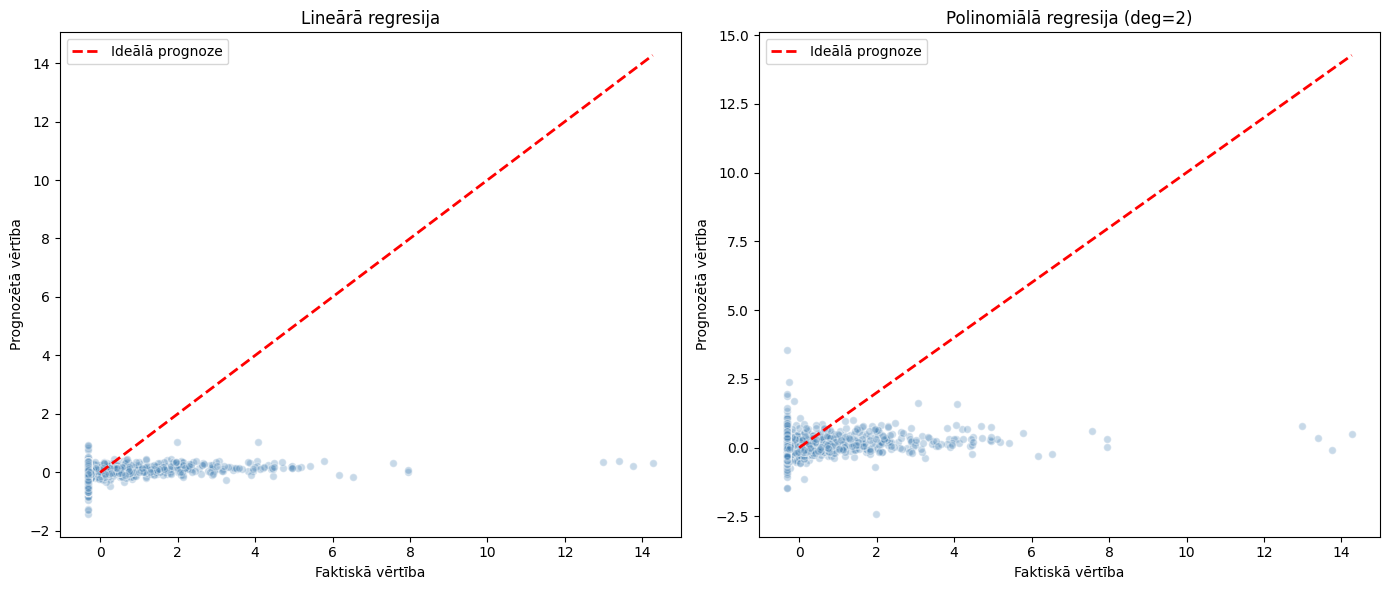

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_p, title in zip(axes,
                           [y_pred, y_pred_poly],
                           ['Lineārā regresija', 'Polinomiālā regresija (deg=2)']):
    ax.scatter(y_test, y_p, alpha=0.3, color='steelblue', edgecolors='white', s=30)
    max_val = max(y_test.max(), y_p.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')
    ax.set_xlabel('Faktiskā vērtība')
    ax.set_ylabel('Prognozētā vērtība')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## Secinājumi

**Kurš modelis labāk prognozē PageValues?**
Abi modeļi uzrāda ļoti zemu R² — lineārā regresija 0.0456, polinomiālā 0.0364.
MAE ziņā polinomiālais ir nedaudz labāks (0.4888 vs 0.5009), taču starpība ir niecīga. Neviens no modeļiem nespēj labi prognozēt PageValues.

**Vai polinomiālais modelis nopietni uzlaboja R²?**
Nē — polinomiālā modeļa Test R² (0.0364) pat ir zemāks nekā lineārās regresijas Test R² (0.0456). Tas nozīmē, ka pievienotā sarežģītība (x² iezīmes) nepalīdzēja, bet nedaudz pasliktināja vispārināšanu.

**Overfitting pazīmes?**
Polinomiālajam modelim Train R² (0.1334) ir ievērojami augstāks nekā Test R² (0.0364) — starpība 0.0971 ir tuvu brīdinājuma robežai (0.10).
Tas liecina, ka modelis sāk pārmācīties. Lineārajai regresijai starpība ir tikai 0.0112 — stabili, bez overfitting.

**Biznesa ieteikums:**
Biznesa vidē es ieteiktu lineāro regresiju — tā ir stabilāka, bez overfitting riska un vieglāk interpretējama. Tomēr ar R² ≈ 0.05 neviens no šiem modeļiem nav pietiekami precīzs reālai lietošanai. Labāks nākamais solis būtu izmēģināt Random Forest Regressor, kas spēj uztvert nelineāras sakarības bez overfitting riska.